In [72]:
import torch
from torch import nn
import matplotlib.pyplot as plt


print("Gpu enabled: ", torch.cuda.is_available())

Gpu enabled:  False


In [ ]:
torch.manual_seed(42)

samples = 100

# Features
hours_studied  = torch.randint(1, 11, (samples, 1)).float()   # 1–10 hrs
hours_slept    = torch.randint(4, 10, (samples, 1)).float()   # 4–9 hrs
practice_tests = torch.randint(0, 11, (samples, 1)).float()   # 0–10 tests

# Stack into X → shape (1000, 3)
X = torch.cat((hours_studied, hours_slept, practice_tests), dim=1)

# Normalize each feature to 0–1
X_min = X.min(dim=0).values
X_max = X.max(dim=0).values
X = (X - X_min) / (X_max - X_min)

# Meaningful weights: hours_studied=15, hours_slept=10, practice_tests=8
weights = torch.tensor([[15.0], [10.0], [8.0]])
bias = 40.0

noise = torch.randn(samples, 1) * 2.5
y = torch.matmul(X, weights) + bias + noise
y = torch.clamp(y, 0, 100)
 
X[:5], y[:5]


(tensor([[0.2222, 0.8000, 0.1000],
         [0.7778, 0.6000, 0.4000],
         [0.6667, 0.6000, 1.0000],
         [0.4444, 1.0000, 0.7000],
         [0.6667, 0.2000, 0.2000]]),
 tensor([[52.1333],
         [60.8667],
         [64.0000],
         [62.2667],
         [53.6000]]))

In [74]:
split_ratio = int(len(X)*0.8)

x_train, y_train = X[:split_ratio], y[:split_ratio]
x_test, y_test = X[split_ratio:], y[split_ratio:]

len(x_train), len(y_train), len(x_test), len(y_test)

(80, 80, 20, 20)

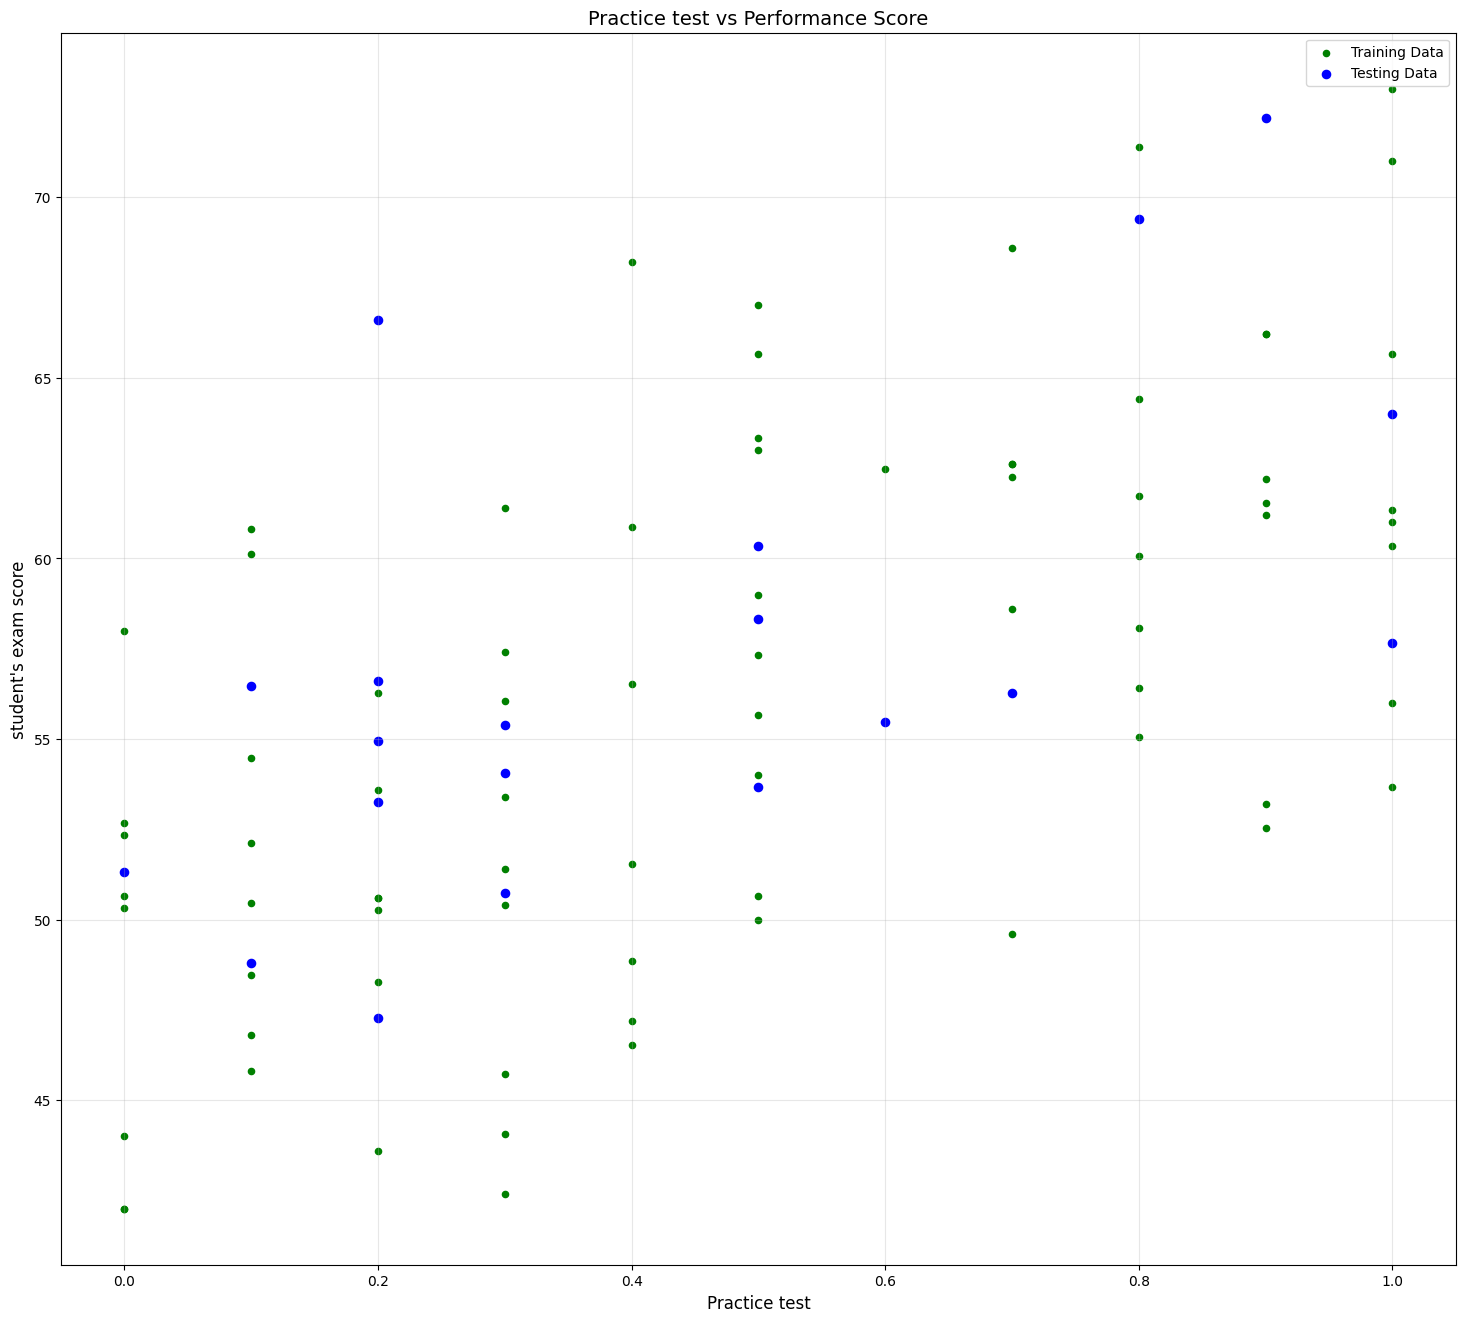

In [75]:
feature_names = [
    "Hours studied",
    "Hours slept",
    "Practice test",
]

def dataset_intuition(
    feature_index=0,
    x_train=x_train,
    y_train=y_train,
    x_test=x_test,
    y_test=y_test,
    predictions=None
):
    plt.figure(figsize=(18, 16))

    plt.scatter(
        x_train[:, feature_index],
        y_train,
        color="green",
        s=20,
        label="Training Data"
    )

    plt.scatter(
        x_test[:, feature_index],
        y_test,
        color="blue",
        s=35,
        label="Testing Data"
    )

    if predictions is not None:
        plt.scatter(
            x_test[:, feature_index],
            predictions,
            color="red",
            s=20,
            label="Predictions"
        )

    plt.xlabel(feature_names[feature_index], fontsize=12)
    plt.ylabel("student's exam score", fontsize=12)
    plt.title(f"{feature_names[feature_index]} vs Performance Score", fontsize=14)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()
    
dataset_intuition(2)

In [76]:
class LinearRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(3,1))
        self.bias = nn.Parameter(torch.Tensor([3.444]))
        
    def forward(self, x):
        return x @ self.weights + self.bias
        

In [77]:
model = LinearRegression()
print(model.state_dict())

OrderedDict({'weights': tensor([[-0.6021],
        [ 0.6732],
        [ 0.0183]]), 'bias': tensor([3.4440])})


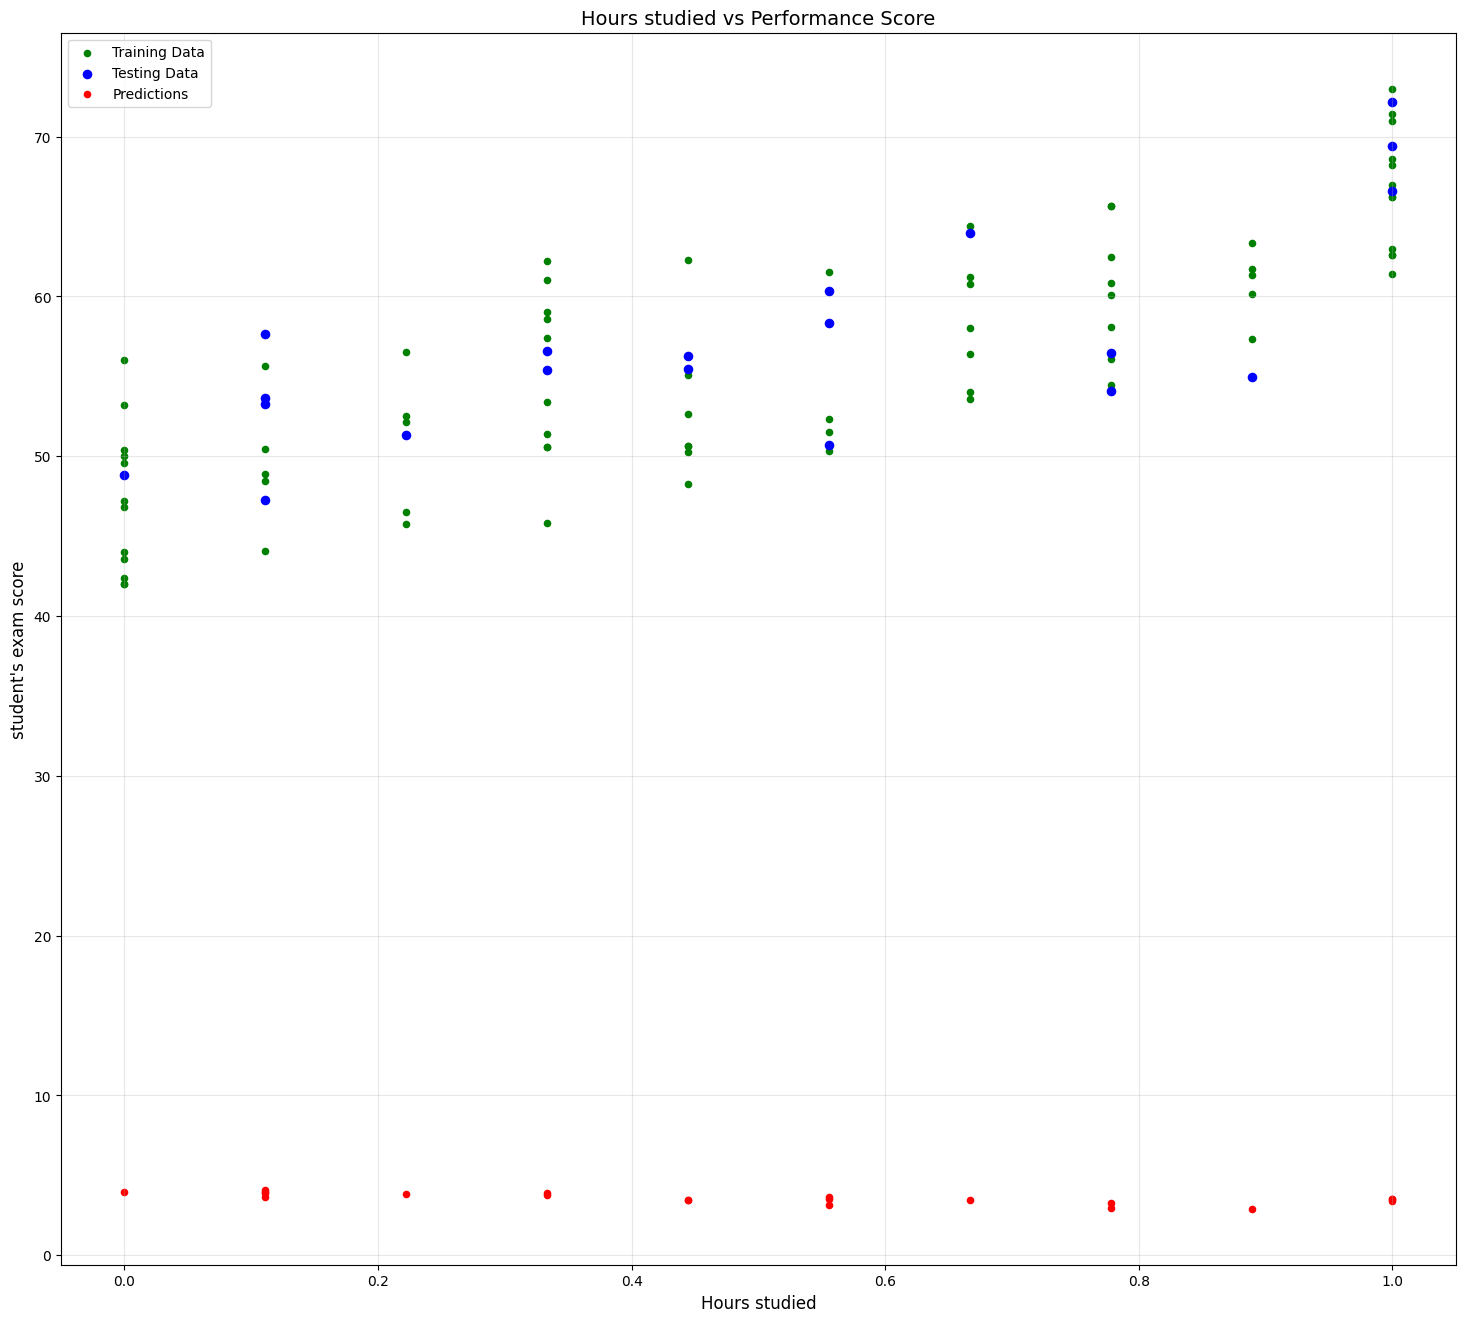

In [78]:
with torch.inference_mode():
    ypred = model(x_test)

dataset_intuition(predictions=ypred)

In [79]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.01)

In [80]:
epochs = 8000

for epoch in range(epochs):
    model_pred = model(x_train)
    loss = loss_fn(model_pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
        
    if epoch % 10 == 0:                        
        print(f"Epoch number: {epoch + 1 } | Train Loss: {loss} ")
    with torch.inference_mode():
        ypred2 = model(x_test)
        test_loss = loss_fn(ypred2, y_test)
        if epoch % 10 == 0:                        
            print(f"Epoch number: {epoch + 1 } | Test Loss: {test_loss} ")
          
    

Epoch number: 1 | Train Loss: 52.5517692565918 
Epoch number: 1 | Test Loss: 53.55430221557617 
Epoch number: 11 | Train Loss: 52.38147735595703 
Epoch number: 11 | Test Loss: 53.37938690185547 
Epoch number: 21 | Train Loss: 52.21118927001953 
Epoch number: 21 | Test Loss: 53.2044677734375 
Epoch number: 31 | Train Loss: 52.04090118408203 
Epoch number: 31 | Test Loss: 53.029541015625 
Epoch number: 41 | Train Loss: 51.87060546875 
Epoch number: 41 | Test Loss: 52.8546257019043 
Epoch number: 51 | Train Loss: 51.7003173828125 
Epoch number: 51 | Test Loss: 52.6796989440918 
Epoch number: 61 | Train Loss: 51.5300178527832 
Epoch number: 61 | Test Loss: 52.504791259765625 
Epoch number: 71 | Train Loss: 51.3597297668457 
Epoch number: 71 | Test Loss: 52.329864501953125 
Epoch number: 81 | Train Loss: 51.1894416809082 
Epoch number: 81 | Test Loss: 52.154945373535156 
Epoch number: 91 | Train Loss: 51.01914596557617 
Epoch number: 91 | Test Loss: 51.98002243041992 
Epoch number: 101 | Tr

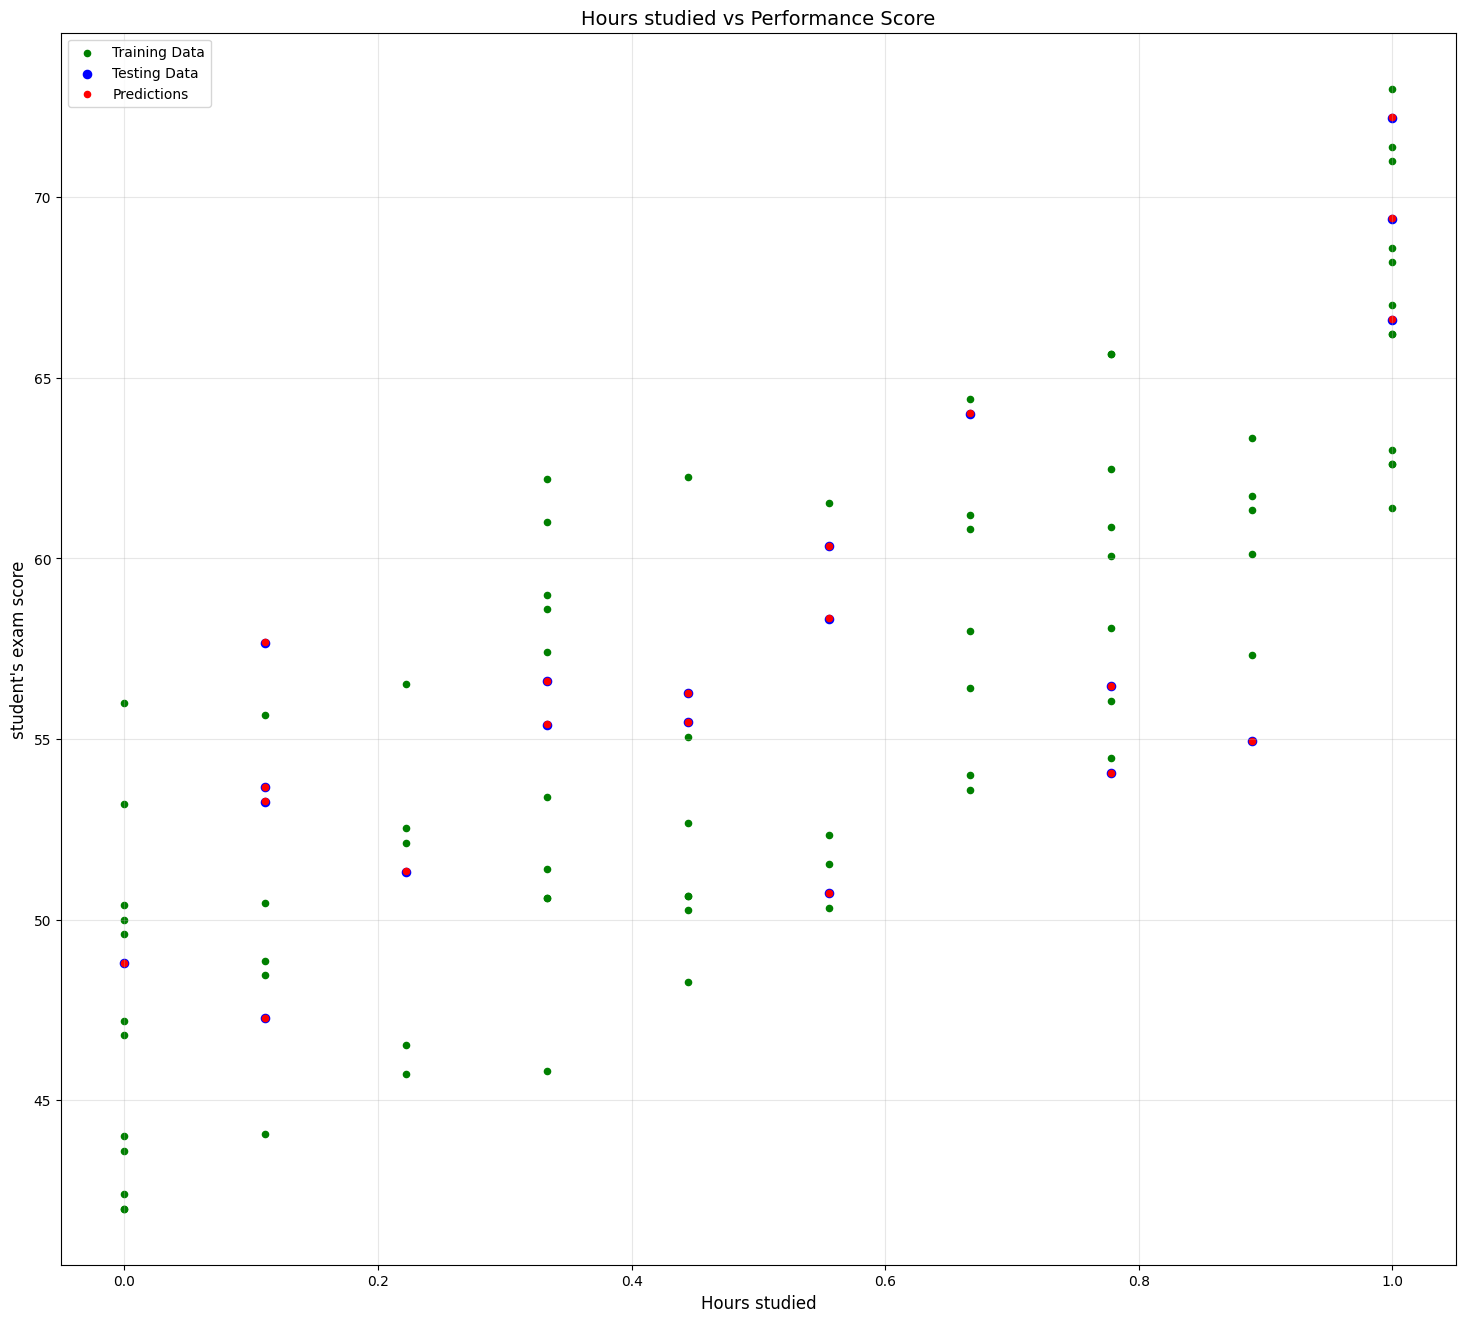

In [81]:
with torch.inference_mode():
    ypred2 = model(x_test)

dataset_intuition(predictions=ypred2)